# Task 1: Iris Flower Classification

## Objective

The Objective of This project Is To Classify iris Flowers Into Three Species:
Setosa, Versicolor, and Virginica Based On Their Physical Measurements.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Iris Dataset

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
print(iris.data.shape)

(150, 4)


## 3. Create DataFrame

In [5]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 4. Add Target Column

In [7]:
df["species"] = iris.target

In [8]:
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


## 5. Exploratory Data Analysis (EDA)

### Dataset Shape

In [11]:
df.shape

(150, 6)

### Data Types

In [12]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

### Missing Values

In [13]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

### Descriptive Statistics

In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 6. Data Visualization

### Species Distribution

In [15]:
df["species_name"].value_counts()

species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

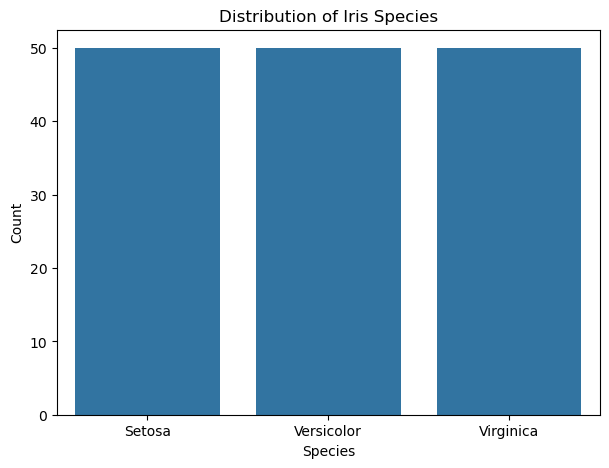

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="species_name")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

### Pairplot

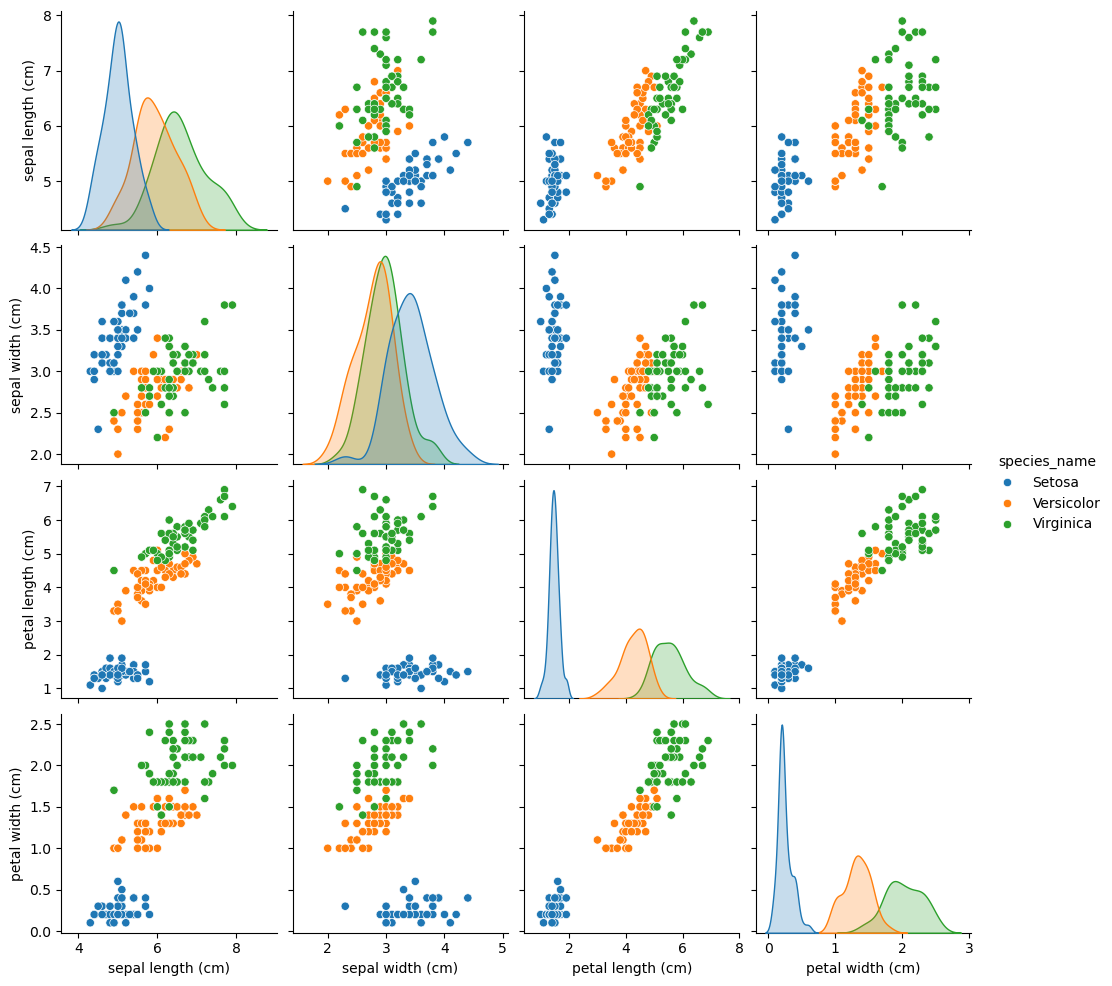

In [20]:
sns.pairplot(
    df,
    hue="species_name",
    vars=iris.feature_names
)

plt.show()

###  Box Plots

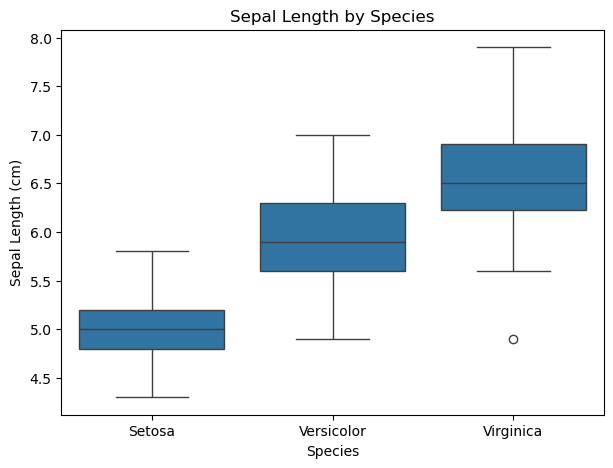

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="species_name",
    y="sepal length (cm)"
)

plt.title("Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length (cm)")
plt.show()

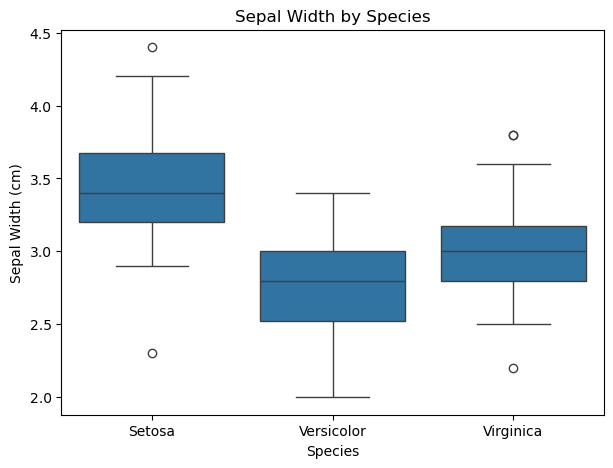

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="species_name",
    y="sepal width (cm)"
)

plt.title("Sepal Width by Species")
plt.xlabel("Species")
plt.ylabel("Sepal Width (cm)")
plt.show()

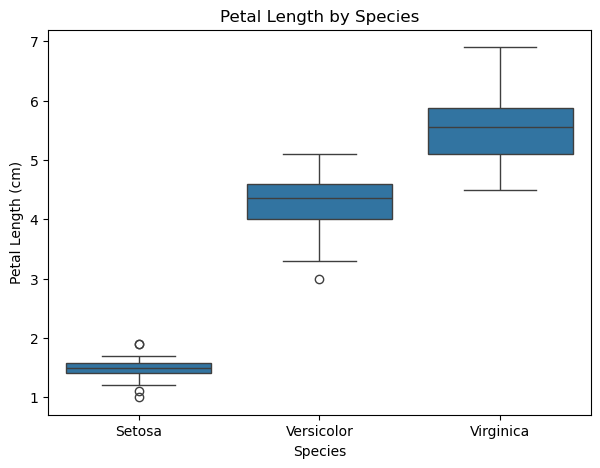

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="species_name",
    y="petal length (cm)"
)

plt.title("Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()

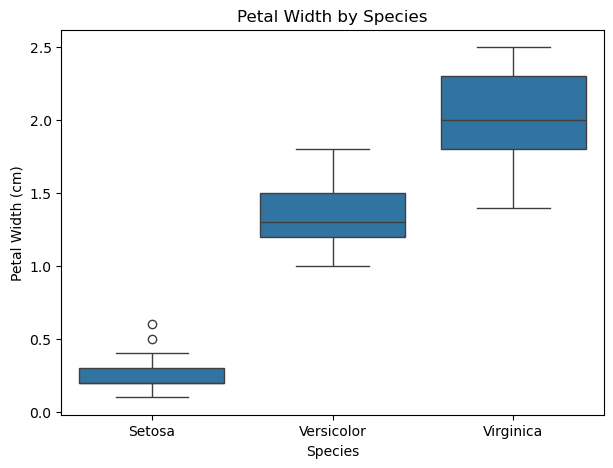

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="species_name",
    y="petal width (cm)"
)

plt.title("Petal Width by Species")
plt.xlabel("Species")
plt.ylabel("Petal Width (cm)")
plt.show()

###  Feature Selection Discussion

Based on the pairplot and Box Plots, Petal Length and Petal Width Appear to
Be the Most Discriminative features.

These two features show a clear separation between the Iris species,
Especially Setosa compared With Versicolor and Virginica.

Sepal Length Also Provides Useful information, But there Is More Overlap
Between the species.

Sepal Width appears to be Comparatively Less Discriminative Because the
Species Show more overlap in this Feature.

Therefore, Petal Length and Petal Width Are Considered the Most useful
features for Distinguishing the Iris Species.

## 7. Prepare Data for Machine Learning

In [27]:
X = df[iris.feature_names]

In [28]:
y = df["species"]

In [29]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## 8. Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


## 9. Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

In [35]:
X_train_scaled = scaler.fit_transform(X_train)

In [39]:
X_test_scaled = scaler.transform(X_test)

In [40]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (120, 4)
Scaled testing data shape: (30, 4)


## 10. Model 1 - Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

### Accuracy Score

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


###  Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix

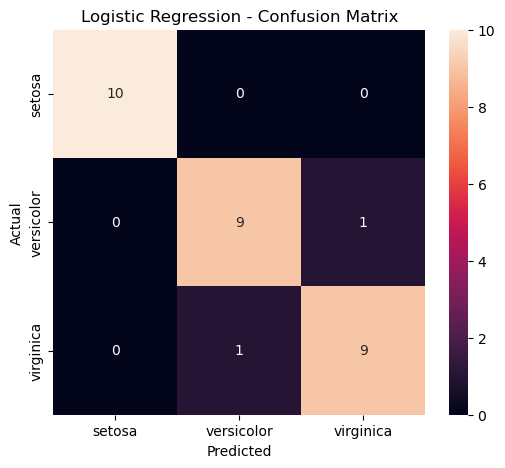

In [46]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [49]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 11. Model 2 - Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [52]:
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred_rf = random_forest_model.predict(X_test)

In [54]:
print(y_pred_rf)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


###  Accuracy Score

In [55]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9


### Confusion Matrix

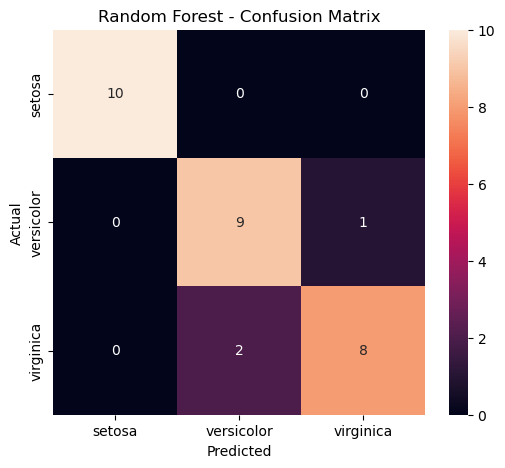

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=iris.target_names
))

## 12. Model Comparison

In [59]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,Random Forest,0.900000


###  Accuracy Comparison

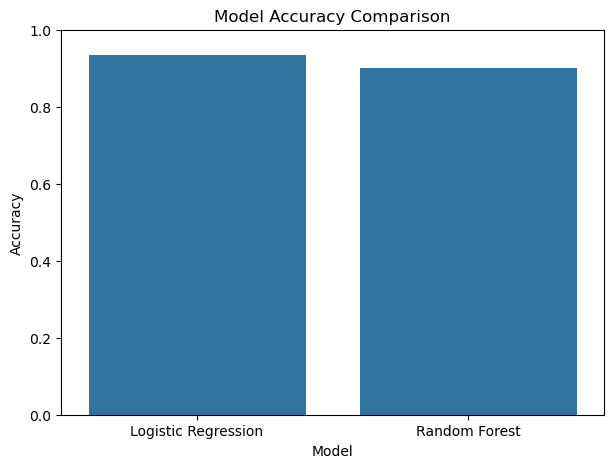

In [60]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

## 13. Best Performing Model

In [61]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Best Model: Logistic Regression
Accuracy: 0.9333333333333333


## 14. Conclusion


### The Iris Flower Classification project was successfully completed using Logistic Regression and Random Forest Classifier.

### Both models were trained and evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

### Logistic Regression achieved an accuracy of 93.33%, while Random Forest achieved an accuracy of 90.00%.

### Based on the test accuracy, Logistic Regression was selected as the best-performing model for this project.

### The exploratory data analysis and visualizations showed that Petal Length and Petal Width were the most discriminative features for distinguishing the three Iris species.

### Overall, the models were able to classify Setosa, Versicolor, and Virginica with good performance.
